# 1. Retrieval-Augmented Generation (RAG)

A general chatbot workflow is as following:

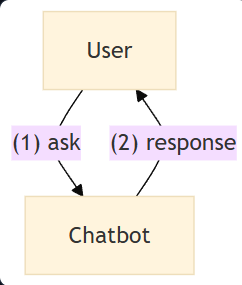

Now what if you ask the chatbot a question that requires specific knowledge? Without providing any knowledge, the model can't reply.

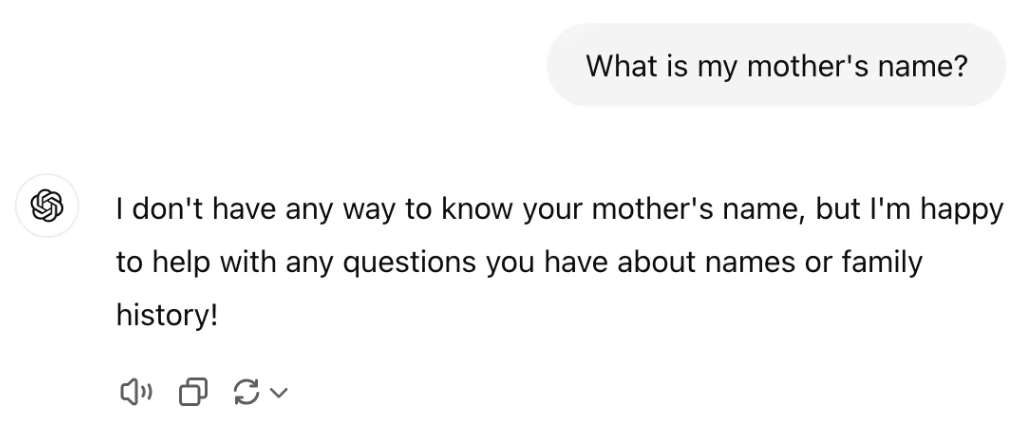

So, we have to use a database, that provides the knowledge to the model. This is called Retrieval-Augmented Generation (RAG).


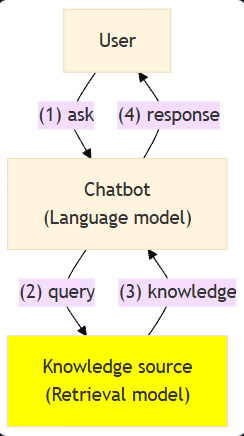

A RAG is implemented in the following way:

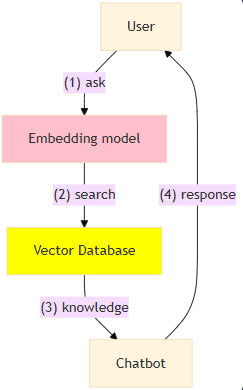

**Components of RAG:**



* Embedding model (Retriever LLM): A pre-trained language model that converts input text into embeddings to capture semantic meaning. These vectors will be used to search for relevant information in the dataset.



* Vector database: A storage system for knowledge and its corresponding embedding vectors.



* Chatbot (Generator LLM): A language model that generates responses based on retrieved knowledge. This can be any language model, such as Llama, Gemma, or GPT.

Creation of database (Chunking):

For generating the database, we break the documents into small chunks, calculate vector representation and store into a vector database. This helps for efficient search.


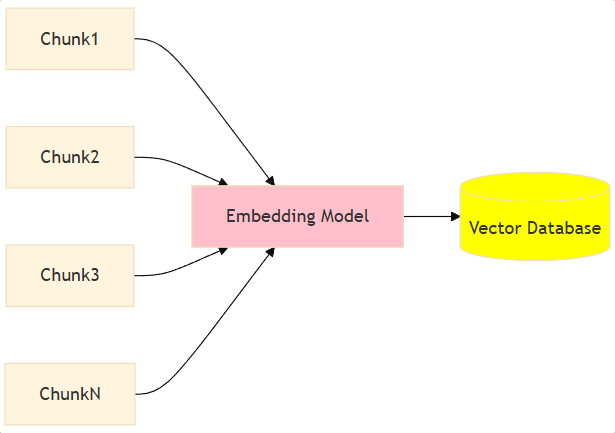

The working of RAG can be seen as:
1. Chunking of the documents, embedding of the chunks using embedding model and store the embedding vectors in vector database.
2. Embedding of the user query using the embedding model.
3. Search the top-k documents by evaluating the similarity between query embedding and the documents embeddings of the vector database.
4. Use the retrieved document embeddings and query embeddings for answer generation with the help of another sequence-to-sequence generator LLM.

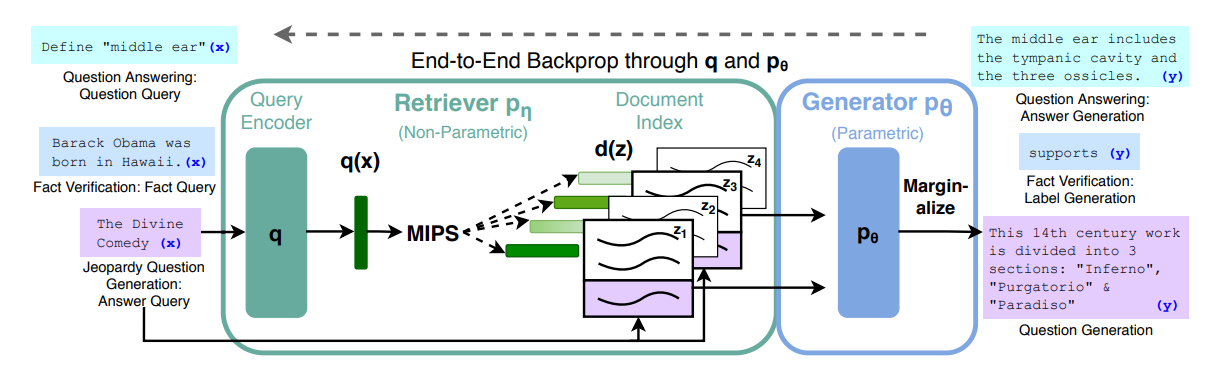

# 2. RAG IMPLEMENTATION

# Installations and Imports

In [ ]:
!pip install -q torch transformers accelerate bitsandbytes langchain sentence-transformers faiss-cpu openpyxl pacmap datasets langchain-community ragatouille

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 16.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.3/303.3 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━

In [ ]:
from tqdm.notebook import tqdm
import pandas as pd
from typing import Optional, List, Tuple
from datasets import Dataset
import matplotlib.pyplot as plt
import datasets
import torch

### imports for models, tokenizers etc.
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from transformers import pipeline, AutoModelForCausalLM, BitsAndBytesConfig


**Langchain:**

LangChain is an open-source tool that helps LLMs work with external data, tools, and memory.

It makes it easier to build smart chatbots, automation systems, and apps that use LLMs.

Unlike direct API calls, LangChain lets models remember context, use tools, and access real information.

In [ ]:
'''
Convert raw text into structured “documents”
Split long text into smaller chunks
Convert chunks into vector embeddings
Store those embeddings in a vector search index (FAISS)
Retrieve the most relevant chunks at query time
'''

### langchain imports
from langchain.docstore.document import Document as LangchainDocument
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy


# 2.1. Step 0: Documents for retrieval:
First we use a dataset, which is used as a collection of documents.

In [ ]:
### dataset
ds = datasets.load_dataset("m-ric/huggingface_doc", split="train")

### Data in the documents
print(ds)
print("\n================================== first document content ==================================\n")
print(ds['text'][0])
print("\n================================== source of the document ==================================\n")
print(ds['source'][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

huggingface_doc.csv:   0%|          | 0.00/22.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2647 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'source'],
    num_rows: 2647
})

================================== first document content ==================================

 Create an Endpoint

After your first login, you will be directed to the [Endpoint creation page](https://ui.endpoints.huggingface.co/new). As an example, this guide will go through the steps to deploy [distilbert-base-uncased-finetuned-sst-2-english](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english) for text classification. 

## 1. Enter the Hugging Face Repository ID and your desired endpoint name:

<img src="https://raw.githubusercontent.com/huggingface/hf-endpoints-documentation/main/assets/1_repository.png" alt="select repository" />

## 2. Select your Cloud Provider and region. Initially, only AWS will be available as a Cloud Provider with the `us-east-1` and `eu-west-1` regions. We will add Azure soon, and if you need to test Endpoints with other Cloud Providers or regions, please let us know.

<img

In [ ]:
### Store documents in langchain framework

RAW_KNOWLEDGE_BASE = [
    LangchainDocument(page_content=doc["text"], metadata={"source": doc["source"]})
    for doc in tqdm(ds)
]

  0%|          | 0/2647 [00:00<?, ?it/s]

# 2.2. Step 1: Document Retrieval



*   **Retriever Embeddings:**

 Works like an internal search engine — given a user query, it retrieves the most relevant text snippets from a knowledge base to help the model generate an answer.


top_k: Number of snippets to retrieve (more snippets = higher chance of relevance).


*   Chunking of Documents:

Documents are split into smaller, semantically meaningful chunks.

Chunking can be done in several ways, e.g., sentence chunking, paragraph chunking, recursive chunking etc.

Recursive chunking uses a hierarchy of separators (e.g., \n\n, \n, ., etc.) to preserve structure while controlling size of the chunks.


*   Parameters:

chunk_size: Defines max characters per chunk.

chunk_overlap: Adds small overlap between chunks to avoid cutting off ideas (commonly 1/10th of chunk size).

LangChain provides flexible tools for splitting, storing, and retrieving chunks with metadata support.

In [ ]:
# Hierarchical list of separators for splitting Markdown documents
MARKDOWN_SEPARATORS = [
    "\n#{1,6} ",        # Markdown headings (#, ##, ..., ######)
    "```\n",            # backtick codeblocks (```)
    "\n\\*\\*\\*+\n",   # asterisks (***)
    "\n---+\n",         # Dashes (---)
    "\n___+\n",         # Underscore (___)
    "\n\n",             # Double newline
    "\n",               # Single newline
    " ",                # Spaces. If text is still too large, it will try splitting at spaces (i.e., word boundaries).
    "",                 # individual characters. The final and smallest level. If no separator fits, it will just split by character count.
]

# Recursive chunking
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,        # The maximum number of characters in a chunk: here, we selected this value arbitrarily
    chunk_overlap=100,      # The number of characters to overlap between chunks
    add_start_index=True,   # If `True`, includes chunk's start index in metadata
    strip_whitespace=True,  # If `True`, strips whitespace from the start and end of every document
    separators=MARKDOWN_SEPARATORS,
)

docs_processed = []
for doc in RAW_KNOWLEDGE_BASE:
    docs_processed += text_splitter.split_documents([doc])


*   **Chunk size and embedder's max seq. length:**

Although we can use higher chunk size for better context, the embedding model's max sequence length restrict the chunk size.

If chunk size is higher than embedder's max sequence length, the model might not capture the embedding of whole chunk, thus, it is mandatory to keep the chunk size less than embedder's max seq. length


*   We use a small model (gte-small) for illustration purpose. It is a BERT-based small Embedding model.

Model Details: https://huggingface.co/thenlper/gte-small#gte-small

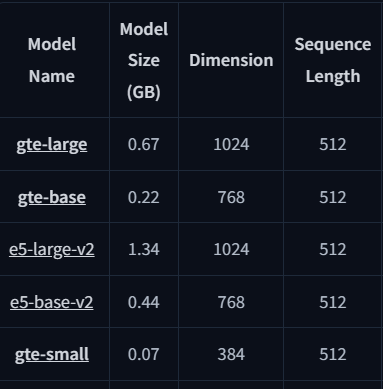



Max. sequence length of this model is 512. So, Chunk size should not exceed 512.

tokenizer_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

  0%|          | 0/31085 [00:00<?, ?it/s]

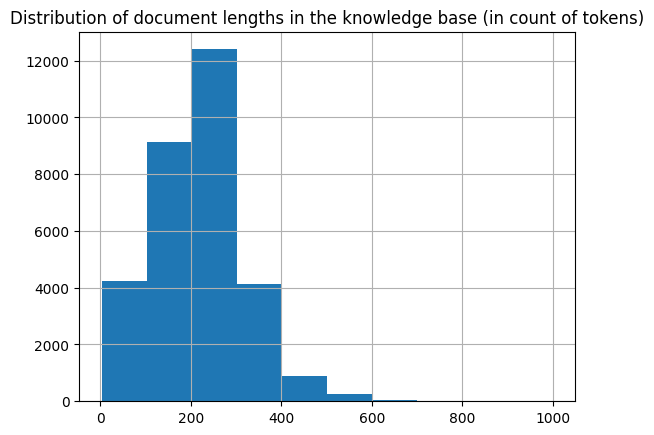

In [ ]:
# Plot the distribution of document lengths, counted as the number of tokens (chunk size 1000)

tokenizer = AutoTokenizer.from_pretrained("thenlper/gte-small")
lengths = [len(tokenizer.encode(doc.page_content)) for doc in tqdm(docs_processed)]

fig = pd.Series(lengths).hist()
plt.title("Distribution of document lengths in the knowledge base (in count of tokens)")
plt.show()

  0%|          | 0/16776 [00:00<?, ?it/s]

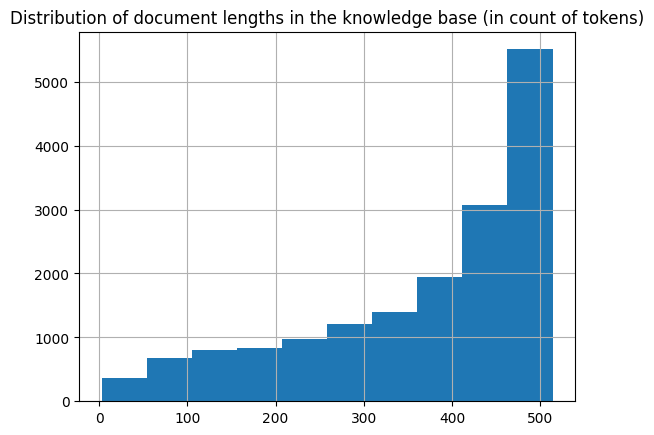

In [ ]:
# Split documents into chunks of maximum size `chunk_size` tokens and return a list of documents.

EMBEDDING_MODEL_NAME = "thenlper/gte-small"


def split_documents(
    chunk_size: int,
    knowledge_base: List[LangchainDocument],
    tokenizer_name: Optional[str] = EMBEDDING_MODEL_NAME,
) -> List[LangchainDocument]:

    text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        AutoTokenizer.from_pretrained(tokenizer_name),
        chunk_size=chunk_size,
        chunk_overlap=int(chunk_size / 10),
        add_start_index=True,
        strip_whitespace=True,
        separators=MARKDOWN_SEPARATORS,
    )

    docs_processed = []
    for doc in knowledge_base:
        docs_processed += text_splitter.split_documents([doc])

    # Remove duplicate document contents (if any)
    unique_texts = {}
    docs_processed_unique = []
    for doc in docs_processed:
        if doc.page_content not in unique_texts:
            unique_texts[doc.page_content] = True
            docs_processed_unique.append(doc)

    return docs_processed_unique


docs_processed = split_documents(
    512,  # We choose a chunk size adapted to our model
    RAW_KNOWLEDGE_BASE,
    tokenizer_name=EMBEDDING_MODEL_NAME,
)

# Let's visualize the chunk sizes we would have in tokens
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)
lengths = [len(tokenizer.encode(doc.page_content)) for doc in tqdm(docs_processed)]
fig = pd.Series(lengths).hist()
plt.title("Distribution of document lengths in the knowledge base (in count of tokens)")
plt.show()

Next, we need to extract document based on the cosine similarity between embedded documents and embedded query. We need to use some search technique to get the most similar (highest cosine similarity) document.

We have used FAISS (Facebook AI Similarity Search), which is an open-source library for fast and efficient similarity search and clustering of dense vectors.
It takes your list of document chunks (docs_processed), converts them into vector embeddings using your embedding_model and stores them in a FAISS index (a structure optimized for similarity search).

In [ ]:
# Initialize the embedding model using Hugging Face
embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,        # Name of the embedding model to use (Here, gte-small)
    multi_process=True,                     # Enables multi-processing for faster embedding generation
    model_kwargs={"device": "cuda"},        # Runs the model on GPU for better performance
    encode_kwargs={"normalize_embeddings": True},  # Normalizes embeddings for cosine similarity calculations
)

# Create a FAISS vector database from processed documents
KNOWLEDGE_VECTOR_DATABASE = FAISS.from_documents(
    docs_processed,                         # The list of document chunks/snippets to store
    embedding_model,                        # The embedding model used to convert text into vectors
    distance_strategy=DistanceStrategy.COSINE  # Uses cosine similarity to measure closeness between embeddings
)


/tmp/ipython-input-2125842537.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/66.7M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Embed a user query in the same space
user_query = "How to create a pipeline object?"
query_vector = embedding_model.embed_query(user_query)

In [ ]:
# Showing the retrieved document and it's details

print(f"\nStarting retrieval for {user_query=}...")
retrieved_docs = KNOWLEDGE_VECTOR_DATABASE.similarity_search(query=user_query, k=5)   # top-k documents to be returned, here k=5
print(
    "\n==================================Full details of Top documents=================================="
)
print(retrieved_docs[0])
print(
    "\n==================================Top document content=================================="
)
print(retrieved_docs[0].page_content)
print("==================================Top document Metadata==================================")
print(retrieved_docs[0].metadata)



Starting retrieval for user_query='How to create a pipeline object?'...

==================================Full details of Top documents==================================
page_content='```
</tf>
</frameworkcontent>

## Pipeline

<Youtube id="tiZFewofSLM"/>

The [`pipeline`] is the easiest and fastest way to use a pretrained model for inference. You can use the [`pipeline`] out-of-the-box for many tasks across different modalities, some of which are shown in the table below:

<Tip>

For a complete list of available tasks, check out the [pipeline API reference](./main_classes/pipelines).

</Tip>' metadata={'source': 'huggingface/transformers/blob/main/docs/source/en/quicktour.md', 'start_index': 1585}

==================================Top document content==================================
```
</tf>
</frameworkcontent>

## Pipeline

<Youtube id="tiZFewofSLM"/>

The [`pipeline`] is the easiest and fastest way to use a pretrained model for inference. You can use the [`pipeline`] out-of-th

# 2.3. Step 2: Answer the user query from the context and retrieved document

Here, we have to use a generator model, which can generate answer of the user query based on the retrieved documents.

We have used a small generator model zephyr-7b-beta, which is a fine-tuned version of Mistral-7B.

Model details: https://huggingface.co/HuggingFaceH4/zephyr-7b-beta

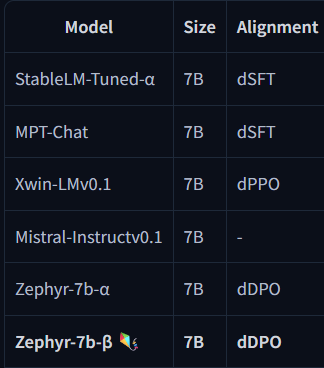

In [ ]:
# Build pipeline for generator model

GENERATOR_MODEL_NAME = "HuggingFaceH4/zephyr-7b-beta"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)
model = AutoModelForCausalLM.from_pretrained(
    GENERATOR_MODEL_NAME, quantization_config=bnb_config
)
tokenizer = AutoTokenizer.from_pretrained(GENERATOR_MODEL_NAME)

GENERATOR_LLM = pipeline(
    model=model,
    tokenizer=tokenizer,
    task="text-generation",
    do_sample=True,
    temperature=0.2,
    repetition_penalty=1.1,
    return_full_text=False,
    max_new_tokens=1000,
)

Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

Device set to use cuda:0


In [ ]:
# Build prompt for generator LLM

prompt_in_chat_format = [
    {
        "role": "system",
        "content": """Using the information contained in the context,
give a comprehensive answer to the question.
Respond only to the question asked, response should be concise and relevant to the question.
Don't show example implementation.
Provide the number of the source document when relevant.
If the answer cannot be deduced from the context, do not give an answer.""",
    },
    {
        "role": "user",
        "content": """Context:
{context}
---
Now here is the question you need to answer.

Question: {question}""",
    },
]
RAG_PROMPT_TEMPLATE = tokenizer.apply_chat_template(
    prompt_in_chat_format, tokenize=False, add_generation_prompt=True
)
print(RAG_PROMPT_TEMPLATE)

<|system|>
Using the information contained in the context,
give a comprehensive answer to the question.
Respond only to the question asked, response should be concise and relevant to the question.
Don't show example implementation.
Provide the number of the source document when relevant.
If the answer cannot be deduced from the context, do not give an answer.</s>
<|user|>
Context:
{context}
---
Now here is the question you need to answer.

Question: {question}</s>
<|assistant|>



Once the user query, retrieved documents and prompt are ready, we can feed that in the generator LLM to get the answer.

In [ ]:
# First, we can check the answer without giving any context (documents' texts)
context = ""

# Add user query and the context (top documents' chunks) to build final prompt
final_prompt = RAG_PROMPT_TEMPLATE.format(
    question="How to create a pipeline object?", context=context
)

# printing the answer
answer = GENERATOR_LLM(final_prompt)[0]["generated_text"]
print(answer)

In Apache Airflow, a pipeline object can be created using the `Airflow` class provided by the library. Here's how:

1. Import the necessary modules:

```python
from airflow import DAG
from datetime import timedelta
```

2. Define the DAG object with its name, start date, schedule interval, etc.:

```python
dag = DAG(
   'my_pipeline',
    default_args=default_args,
    start_date=datetime(2021, 1, 1),
    schedule_interval='@daily'
)
```

3. Create the pipeline object by passing the DAG object as an argument to the `Pipeline` constructor:

```python
pipeline = Pipeline(dag)
```

This creates a new pipeline object that can be used to define tasks and operators within the DAG. Note that this assumes you have already defined the `default_args` dictionary for your DAG's default arguments. If you haven't done so yet, you can create it like this:

```python
default_args = {
    'owner': 'your_username',
   'start_date': datetime(2021, 1, 1),
   'retries': 1,
   'retry_delay': timedelta(minut

Here, the context of huggingface hasn't been given. So, it gives some context which was already seen by the generator model during training.

In [ ]:
# Here, we give the context from the documents
retrieved_docs_text = [
    doc.page_content for doc in retrieved_docs
]  # We only need the text of the documents
context = "\nExtracted documents:\n"
context += "".join(
    [f"Document {str(i)}:::\n" + doc for i, doc in enumerate(retrieved_docs_text)]
)

# Add user query and the context (top documents' chunks) to build final prompt
final_prompt = RAG_PROMPT_TEMPLATE.format(
    question="How to create a pipeline object?", context=context
)

# printing the answer
answer = GENERATOR_LLM(final_prompt)[0]["generated_text"]
print(answer)

To create a pipeline object, follow these steps:

1. Define the inputs and outputs of your pipeline. These could be strings, dictionaries, or any other format that suits your use case.

2. Create a subclass of `Pipeline` and override the following methods:
   - `_sanitize_parameters`: This method takes the parameters passed to the pipeline and returns a tuple containing the preprocess parameters, the forward pass parameters, and the postprocess parameters.
   - `preprocess`: This method takes the inputs and any additional arguments and returns a dictionary containing the inputs in the correct format for the model.
   - `_forward`: This method performs the actual computation using the model and scheduler.
   - `postprocess`: This method takes the output of the forward pass and returns the final result.

3. Inherit the `DiffusionPipeline` class instead of `Pipeline` if you're working with diffusion models.

4. Instantiate your pipeline class and pass it the necessary arguments, such as t

Now, by giving the context, the model includes the context from the huggingface dataset and retrieve corresponding data from that database. This is how RAG becomes more useful than general LLM text generation.